# 06 – Gaussian Naive Bayes

Review 1 Part-A classification.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from classification_utils import (
    load_data,
    prepare_target,
    make_split,
    make_preprocessor,
    make_pipeline
)

# Load dataset
df, feature_cols = prepare_target(
    load_data()
)

# Stratified 80:20 train-test split
X_train, X_test, y_train, y_test, le = make_split(
    df,
    feature_cols
)

# Preprocessing
preprocessor = make_preprocessor(
    X_train
)

# Gaussian Naive Bayes model
model = GaussianNB()

# Complete preprocessing + model pipeline
pipe = make_pipeline(
    model,
    preprocessor
)

# Train
pipe.fit(
    X_train,
    y_train
)

# Predict
y_pred = pipe.predict(
    X_test
)

# Evaluation metrics
metrics = {
    "Model": "Gaussian Naive Bayes",
    "Accuracy": accuracy_score(
        y_test,
        y_pred
    ),
    "Precision": precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    ),
    "Weighted F1": f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )
}

# Display metrics
results = pd.DataFrame([metrics])

display(
    results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "Weighted F1": "{:.4f}"
    })
)

# Classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,Weighted F1
0,Gaussian Naive Bayes,0.5913,0.6499,0.5913,0.5706


Classification Report:
              precision    recall  f1-score   support

       Bumps       0.49      0.67      0.57        81
   Dirtiness       0.83      0.45      0.59        11
    K_Scatch       0.76      0.90      0.82        78
Other_Faults       0.69      0.25      0.37       135
      Pastry       0.32      0.75      0.45        32
      Stains       0.57      0.93      0.70        14
   Z_Scratch       0.86      0.79      0.82        38

    accuracy                           0.59       389
   macro avg       0.65      0.68      0.62       389
weighted avg       0.65      0.59      0.57       389



## Confusion Matrix

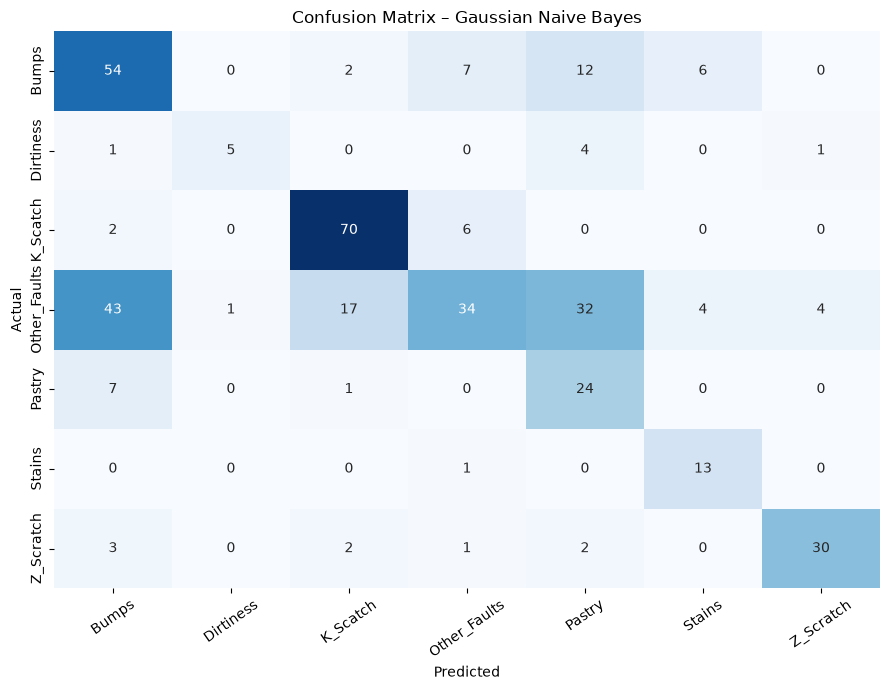

In [6]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix – Gaussian Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(rotation=35)

plt.tight_layout()
plt.show()

### Observation

The diagonal cells in the confusion matrix denote correct classification, whereas the off-diagonal cells indicate fault-type confusions. The above values of Accuracy, Precision, Recall, and F1 represent the performance of the model on the test set.